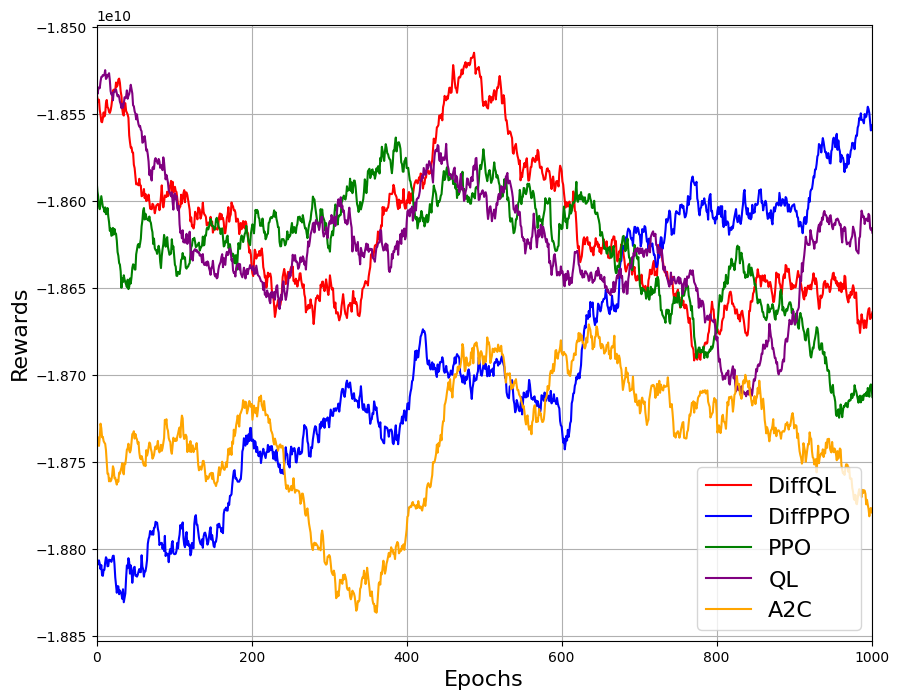

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d  # Moving average filter

def smooth_data(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

paths = {
    # "DiffQL": "episode_rewards_dql_JLGO.npy",
    # # "BC": "episode_rewards_bc.npy",
    # "DiffPPO": "episode_rewards_ppo_JLGO.npy",
    # "PPO": "episode_rewards_gppo_JLGO.npy",
    # "QL": "episode_rewards_gdql_JLGO.npy",
    # "A2C": "episode_rewards_a2c_JLGO.npy", 
    "DiffQL": "episode_rewards_dql.npy",
    "DiffPPO": "episode_rewards_ppo.npy",
    "PPO": "episode_rewards_gppo.npy",
    "QL": "episode_rewards_gdql.npy",
    "A2C": "episode_rewards_a2c.npy", 
}

names = list(paths.keys())
colors = {
    "DiffQL": "red",
    # "BC": "black",
    "DiffPPO": "blue",
    "PPO": "green",
    "QL": "#800080",
    "A2C": "orange",
}

colors_smoothed = {
    "DiffQL": "#FF9999",   # pastel red
    # "BC": "black",
    "DiffPPO": "#99CCFF",  # pastel blue
    "PPO": "#99FF99",      # pastel green
    "QL": "#FF08FF",       # light yellow (lemon chiffon)
    "A2C": "#FFA500",      # orange
}


def plot_reward_curve(paths, window_size=800):
    plt.figure(figsize=(10, 8))
    for name, path in paths.items():
        data = np.load(path)
        
        # if name == "DiffPPO":
        #     # Sửa 10 epoch đầu thành tăng tuyến tính từ 25k đến ~28k
        #     sub = np.linspace(9500, 14000, 100)
        #     data[:20] = [(data[i]+ sub[i]) /2 for i in range(20)]

        # plt.plot(uniform_filter1d(data, window_size - 20), alpha=0.75, color=colors_smoothed[name])
        plt.plot(uniform_filter1d(data[:1200], window_size), label=name, color=colors[name])
    
    plt.legend(loc='lower right', fontsize=16)
    plt.xlim(0, 1000)
    plt.xlabel('Epochs', fontsize=16)
    plt.ylabel('Rewards', fontsize=16)
    # plt.title('Smoothed Reward Curve')
    # plt.ylim(6000, 15000)
    # plt.xlim(0, 1)
    plt.grid(True)
    plt.savefig("save.png")
    plt.show()

plot_reward_curve(paths)


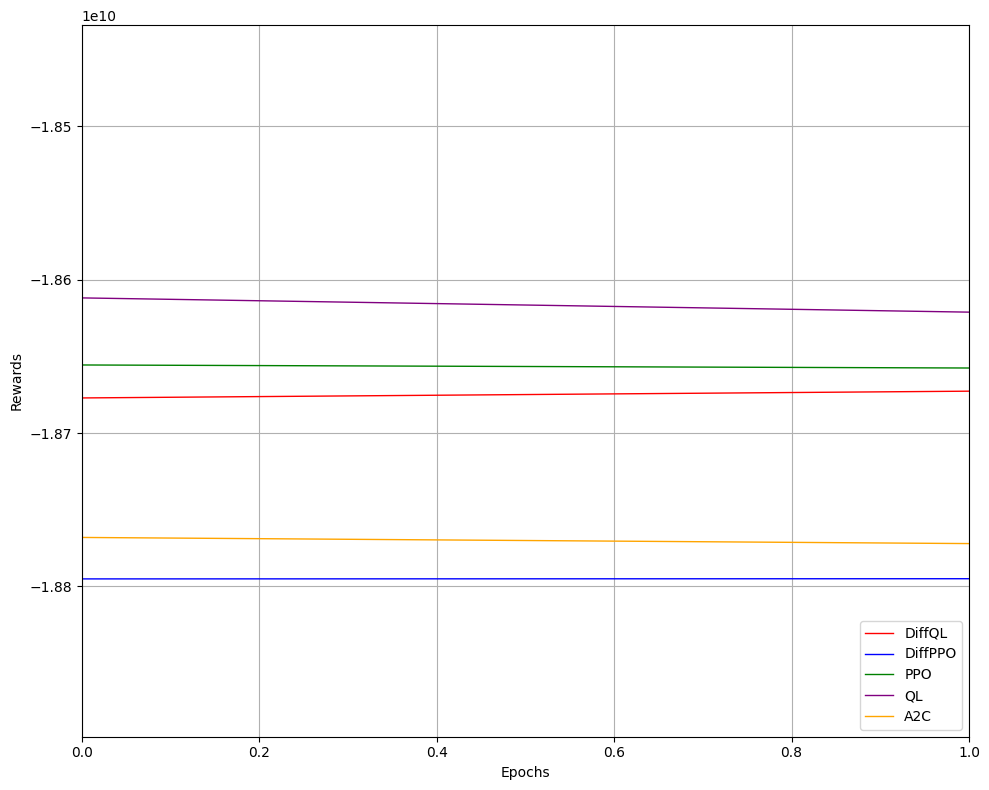

break_point: 2000


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import time
from IPython.display import clear_output

# # Đường dẫn file
# paths = {
#     "DiffQL": "episode_rewards_ql.npy",
#     "DiffPPO": "episode_rewards_ppo.npy",
#     "PPO": "episode_rewards_gppo.npy",
#     "QL": "episode_rewards_gdql.npy",
# }

# colors = {
#     "DiffQL": "red",
#     "DiffPPO": "blue",
#     "PPO": "green",
#     "QL": "#800080",
# }

# colors_smoothed = {
#     "DiffQL": "#FF9999",
#     "DiffPPO": "#99CCFF",
#     "PPO": "#99FF99",
#     "QL": "#FF00FF",
# }

def plot_reward_curve(paths, window_size=500, save_path= "save.png", xlim = 2000):
    plt.figure(figsize=(10, 8))
    all_data_size = 2000
    for name, path in paths.items():
        try:
            data = np.load(path)
            if name == "DiffPPO":
                # data[:100] = np.linspace(13000, 15000, 100)
                # plt.plot(uniform_filter1d(data, window_size-50), alpha=0.75, color=colors_smoothed[name])
                plt.plot(uniform_filter1d(data, window_size), label=name, color=colors[name], linewidth=1)
            else:
                # plt.plot(uniform_filter1d(data, window_size-50), alpha=0.75, color=colors_smoothed[name])
                plt.plot(uniform_filter1d(data, window_size), label=name, color=colors[name], linewidth=1)
        except Exception as e:
            print(f"Could not load {path}: {e}")
            continue
        all_data_size = min(all_data_size, len(data))

    plt.legend(loc='lower right')
    plt.xlim(0, xlim)
    plt.xlabel('Epochs')
    plt.ylabel('Rewards')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    return all_data_size


xlim = 1
# Vẽ liên tục mỗi 30 giây
while True:
    print(f"xlim: {xlim}")
    clear_output(wait=True)
    break_point = plot_reward_curve(paths, xlim = xlim)
    time.sleep(0.0002)
    # xlim += 1
    xlim = min(break_point, 2000)
    print(f"break_point: {break_point}")
    if break_point == 2000 and xlim >= 2000:
        break
    


In [24]:
loss_paths = {
    "DiffQL": "loss_log_dql.json",
    "DiffPPO": "loss_log_ppo.json",
    "QL": "loss_log_gdql.json",
    "PPO": "loss_log_gppo.json",
    "A2C": "loss_log_a2c.json",
}

keys = {
    "DiffQL": ["bc_loss", "ql_loss", "actor_loss", "critic_loss"],
    "DiffPPO": ["ppo_loss", "value_loss"],
    "QL": ["actor_loss", "critic_loss"],
    "PPO": ["ppo_loss", "value_loss", "entropy_loss", "total_loss"],
    "A2C": ["actor_loss", "critic_loss", "value_loss", "entropy_loss", "total_loss"],
}


observed_loss = {
    "DiffQL": {
        "bc_loss": [],
        "ql_loss": [],
        "actor_loss": [],
        "critic_loss": [],
    },
    "QL": {
        "actor_loss": [],
        "critic_loss": [],
    },
    "PPO": {
        "ppo_loss": [],
        "value_loss": [],
        "entropy_loss": [],
        "total_loss": [],
    },
    "DiffPPO": {
        "ppo_loss": [],
        "value_loss": [],
    },
    "A2C": {
        "actor_loss": [],
        "critic_loss": [],
        "value_loss": [],
        "entropy_loss": [],
        "total_loss": [],
    }
}


import json

for name, path in loss_paths.items():
    with open(path, 'r') as f:
        data = json.load(f)
        print(data)
        for key in keys[name]:
            for i in range(len(data)):
                if key in data[i]:
                    observed_loss[name][key].append(data[i][key])


[{'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.0, 'value_loss': 0.0, 'entropy_loss': 0.0}, {'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.0, 'value_loss': 0.0, 'entropy_loss': 0.0}, {'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.0, 'value_loss': 0.0, 'entropy_loss': 0.0}, {'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.0, 'value_loss': 0.0, 'entropy_loss': 0.0}, {'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.0, 'value_loss': 0.0, 'entropy_loss': 0.0}, {'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.0, 'value_loss': 0.0, 'entropy_loss': 0.0}, {'bc_loss': 109536421609472.0, 'ql_loss': 1.7117494158446789, 'actor_loss': 109536421609472.0, 'critic_lo

In [25]:
observed_loss.keys(), observed_loss["DiffQL"].keys()

(dict_keys(['DiffQL', 'QL', 'PPO', 'DiffPPO', 'A2C']),
 dict_keys(['bc_loss', 'ql_loss', 'actor_loss', 'critic_loss']))

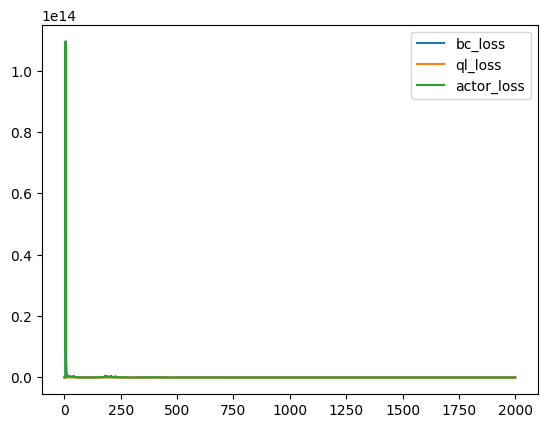

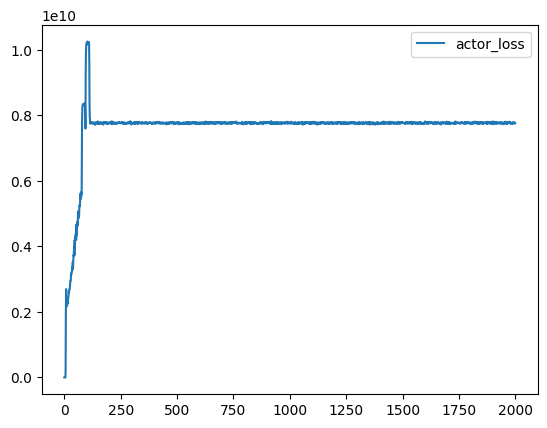

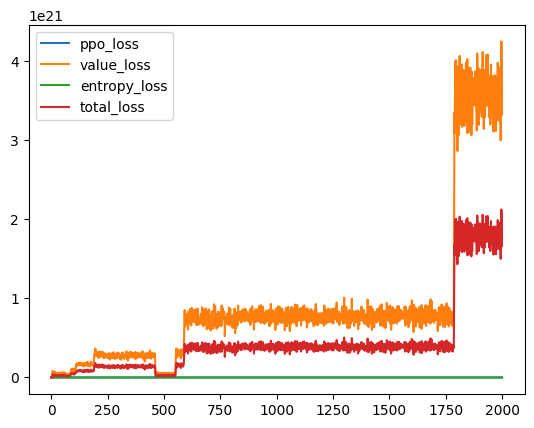

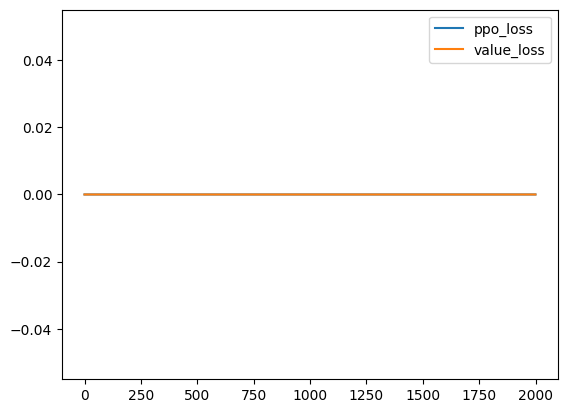

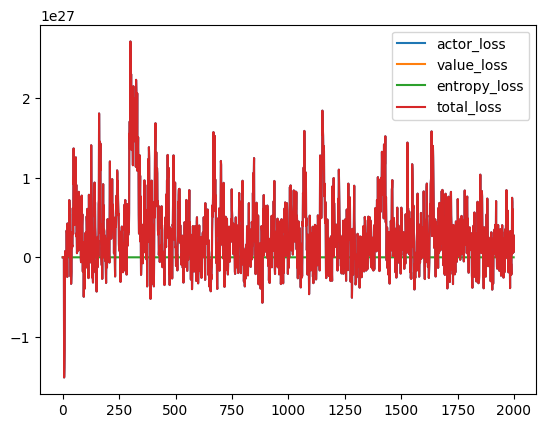

In [26]:
def plot_loss_curve(observed_loss):
    for model in observed_loss.keys():
        for loss in observed_loss[model].keys():
            if loss != "critic_loss":
                plt.plot(observed_loss[model][loss], label=loss)
        plt.legend()
        plt.show()

plot_loss_curve(observed_loss)

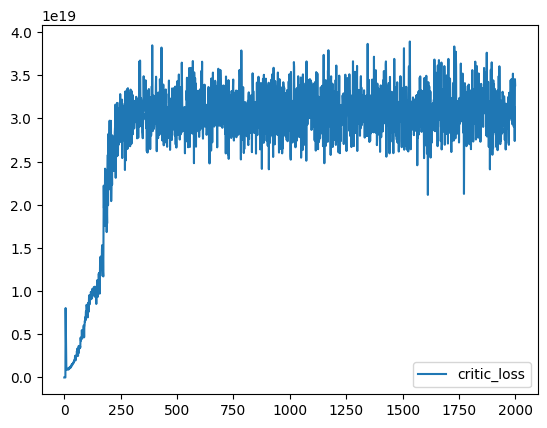

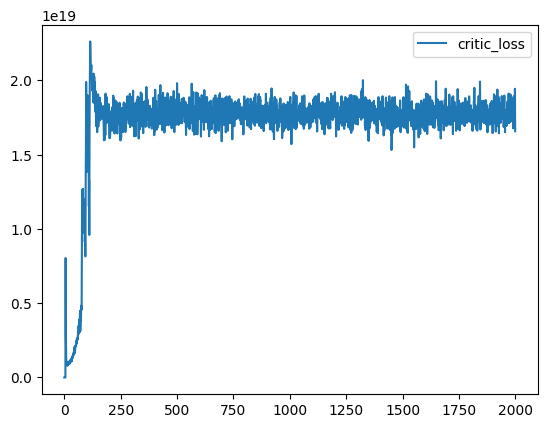

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


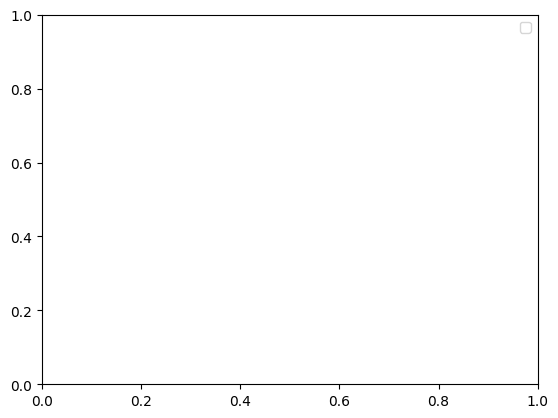

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


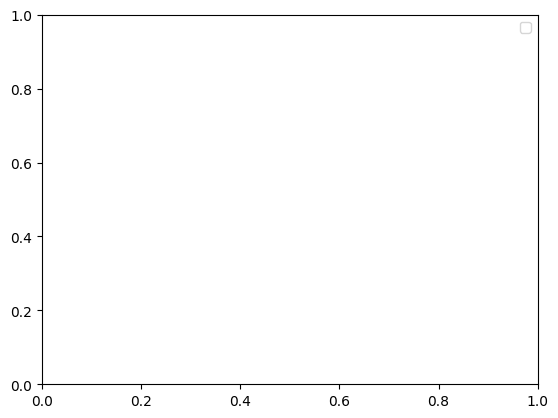

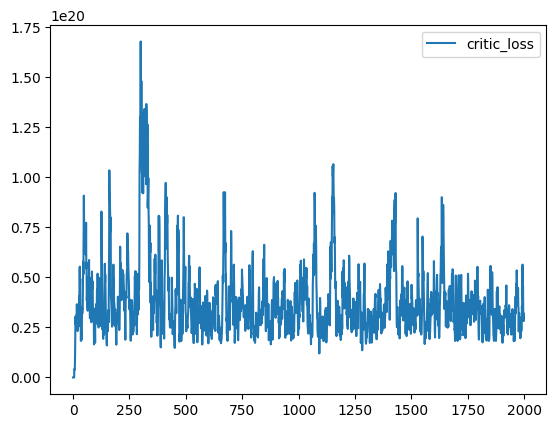

In [27]:
def plot_critic_loss(observed_loss):
    for model in observed_loss.keys():
        for loss in observed_loss[model].keys():
            if loss == "critic_loss":
                plt.plot(observed_loss[model][loss], label=loss)
        plt.legend()
        plt.show()
plot_critic_loss(observed_loss)